In [1]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [139]:
data = pd.read_csv(R"C:\Users\G.B\Desktop\osam\المرحلة الثانية\data science\NLP\SMSSpamCollection.csv",sep='\t')
data.columns = ['label']

In [140]:
data.head()

,label
0,spam\tFree entry in 2 a wkly comp to win FA Cu...
1,"ham\tNah I don't think he goes to usf, he live..."
2,ham\tEven my brother is not like to speak with...
3,ham\tI HAVE A DATE ON SUNDAY WITH WILL!!
4,ham\tAs per your request 'Melle Melle (Oru Min...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5569 entries, 0 to 5568
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                    --------------  ----- 
 0   ham	I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.  5569 non-null   object
dtypes: object(1)
memory usage: 43.6+ KB


In [ ]:
data.describe()

In [ ]:
data.isnull().sum()

In [ ]:
data =data.dropna()

In [ ]:
data.isnull().sum()

In [ ]:
data.info()

In [ ]:
 data.head()

In [ ]:
 data.columns=['text','state'] # state true  = 1 false =-1  normal =0

In [ ]:
data.head()

In [ ]:
data.shape 

In [ ]:
data.state.value_counts(normalize=True)

In [ ]:
import string as s 
s.punctuation # function have all punctuations

In [ ]:
prot = s.punctuation # load all in var 
text = "hell, osam; and ali (dd)" # text to test
new_text = "" 
for char in text:
    if char not in prot:
        # if is not punctuation write in the new var to load text
        new_text=new_text+char
 

In [ ]:
new_text

In [ ]:
data.head()

In [ ]:
def removepunct(text):
    newtext=''.join([char for char in text if char not in s.punctuation])
    return newtext
data['a']=data['text'].apply(lambda x: removepunct(x)) # create new column have data from text
# lambda  let you to us function in function
# put all data in x than put x in function removepunct than the return value of funct apply in new column
#removepunct(data['text'])

####  get out all punctuation !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}

In [ ]:
data.head()

### tokenization

In [ ]:
import re

In [ ]:
text="hello osam, tell me why you dond! like me"
tok=re.split('\W',text)
tok

In [ ]:
newtok=[]
for i in range(len(tok)):
    if tok[i]!='':
        newtok.append(tok[i])
newtok

In [ ]:
from nltk.tokenize import word_tokenize as wt
from nltk.corpus import stopwords

In [ ]:
def token(text):
    # tok = wt(text) but it need net
    tokn = re.split('\W',text)
    return tokn
data['tok']=data['a'].apply(lambda x: token(x))

### devid all the sntant to wor tell me why = [tell,my,why] in column tok

In [ ]:
data.head()

 ### remove stop words

In [ ]:
nltk.download('stopwords')

In [ ]:
stop_word =nltk.corpus.stopwords.words('english')

In [ ]:
stop_word

In [ ]:
def removestop(text):
    textt =[word for word in text if word not in stop_word ]
    return textt
data['stop']=data['tok'].apply(lambda x: removestop(x))

### take all stop_word of column tok to ne column stop

##### som tim there porblem with not and   i not like this = [i,like,this] 

In [ ]:
data.head()

In [ ]:
import nltk

# stemming 

###  عملية تقليل الكلمات وارجاعها الى اصلها وايجاد العلاقة بينهم

#### some Error
###### over stemming = universat + university  = universo there is diffrent

In [ ]:
po =nltk.porter.PorterStemmer()

In [ ]:
print(po.stem('play'))
print(po.stem('playing'))
print(po.stem('plays'))
print(po.stem('played'))

In [ ]:
def stemming(text):
    textt =[po.stem(word) for word in text]
    return textt
data['stemming']=data['stop'].apply(lambda x: stemming(x))

In [ ]:
data.head()

# lemmatizing

### يستخدم قاموس

In [ ]:
nltk.download('wordnet')

In [ ]:
lem  =nltk.wordnet.WordNetLemmatizer()

In [ ]:
print(lem.lemmatize('askings'))
print(lem.lemmatize('plaesing'))
print(lem.lemmatize('plays'))
print(lem.lemmatize('player'))

In [ ]:
data.head()

In [ ]:
def lemmatizing(text):
    textt =[lem.lemmatize(word) for word in text]
    return textt
data['lemmatizing']=data['stop'].apply(lambda x: lemmatizing(x))

In [ ]:
data.head()

# make all this in one def

In [141]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string as s
import re

In [142]:
data = pd.read_csv(R"C:\Users\G.B\Desktop\osam\المرحلة الثانية\data science\NLP\‏‏Twitter_Data.csv")

In [143]:
data.columns =['text','stat']

In [144]:
data = data[["stat","text"]]

In [145]:
data =data.dropna()

In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   stat    180 non-null    float64
 1   text    180 non-null    object 
dtypes: float64(1), object(1)
memory usage: 4.2+ KB


In [147]:
data.head()

,stat,text
0,-1.0,when (modi) promised “minimum government maxim...
1,0.0,talk all the nonsense and continue all the dra...
2,1.0,what did just say vote for modi welcome bjp t...
3,1.0,asking his supporters prefix chowkidar their n...
4,1.0,answer who among these the most powerful world...


In [148]:
nltk.download('stopwords')# wordnet

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [149]:
stop_word =nltk.corpus.stopwords.words('english')

In [150]:
po =nltk.porter.PorterStemmer()

In [151]:
def processing(text):
    newtext=' '.join([char for char in text if char not in s.punctuation])
    tokn = re.split('\W',text)
    lasttext=' '.join([po.stem(char) for char in tokn if char not in stop_word])
    return lasttext
data['summary']=data['text'].apply(lambda x: processing(x)) 

In [152]:
data.head()

,stat,text,summary
0,-1.0,when (modi) promised “minimum government maxim...,modi promis minimum govern maximum govern ...
1,0.0,talk all the nonsense and continue all the dra...,talk nonsens continu drama vote modi
2,1.0,what did just say vote for modi welcome bjp t...,say vote modi welcom bjp told rahul main camp...
3,1.0,asking his supporters prefix chowkidar their n...,ask support prefix chowkidar name modi great s...
4,1.0,answer who among these the most powerful world...,answer among power world leader today trump pu...


In [153]:
s ="As s"
s.split('\w')

['As s']

## vetorizing  

## is processing data to way can langaug kow it

### count vectorization : output matrix count of rows  is  documnt term ; columns is the word dedicted

In [154]:
mass = ["good mass","not","good mass","did not like","i like it"]

In [155]:
from sklearn.feature_extraction.text import CountVectorizer

In [156]:
vectcoun = CountVectorizer()
feature_cv = vectcoun.fit_transform(data["summary"])
print(feature_cv.shape)
print(feature_cv)
feature_cv =pd.DataFrame(feature_cv.toarray())
feature_cv.columns = vectcoun.get_feature_names_out()
feature_cv

(180, 1165)
  (0, 683)	1
  (0, 818)	1
  (0, 668)	1
  (0, 422)	2
  (0, 650)	1
  (0, 338)	1
  (0, 106)	1
  (0, 277)	1
  (0, 534)	1
  (0, 857)	1
  (0, 975)	2
  (0, 1003)	1
  (0, 1157)	1
  (0, 410)	1
  (0, 541)	1
  (0, 146)	1
  (0, 337)	1
  (0, 830)	1
  (0, 1018)	1
  (1, 683)	1
  (1, 1007)	1
  (1, 725)	1
  (1, 213)	1
  (1, 297)	1
  (1, 1103)	1
  :	:
  (176, 1032)	2
  (176, 617)	1
  (177, 683)	1
  (177, 772)	1
  (177, 970)	1
  (177, 1085)	1
  (177, 1104)	1
  (177, 729)	1
  (177, 86)	1
  (178, 683)	1
  (178, 1103)	1
  (178, 842)	1
  (178, 1041)	1
  (178, 400)	1
  (178, 792)	2
  (178, 255)	1
  (178, 615)	2
  (178, 444)	2
  (179, 683)	1
  (179, 194)	1
  (179, 967)	1
  (179, 1054)	1
  (179, 237)	1
  (179, 345)	1
  (179, 994)	1


,100,2010,2014,2019,2025,2nd,3040,3month,45yrhigh,474,...,yawnn,ye,year,yet,yogi,youth,yr,yuvanestam,zindabad,शबच
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
176,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
177,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
178,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### count حالة خاصة من N-gram

In [157]:
ngram =CountVectorizer(ngram_range=(1,2)) # style for ngram
ngram_fit = ngram.fit_transform(data["summary"])
print(ngram_fit.shape)
print(ngram_fit)
ngram_fit =pd.DataFrame(ngram_fit.toarray())
ngram_fit.columns = ngram.get_feature_names_out()
ngram_fit

(180, 3213)
  (0, 1787)	1
  (0, 2288)	1
  (0, 1753)	1
  (0, 1105)	2
  (0, 1714)	1
  (0, 885)	1
  (0, 266)	1
  (0, 710)	1
  (0, 1402)	1
  (0, 2391)	1
  (0, 2672)	2
  (0, 2750)	1
  (0, 3186)	1
  (0, 1065)	1
  (0, 1422)	1
  (0, 365)	1
  (0, 883)	1
  (0, 2318)	1
  (0, 2802)	1
  (0, 1871)	1
  (0, 2292)	1
  (0, 1754)	1
  (0, 1113)	1
  (0, 1715)	1
  (0, 1109)	1
  :	:
  (178, 1171)	2
  (178, 1868)	1
  (178, 2226)	1
  (178, 2351)	1
  (178, 1043)	1
  (178, 2229)	1
  (178, 1616)	1
  (178, 658)	1
  (178, 1177)	1
  (178, 2872)	1
  (178, 3025)	1
  (178, 1617)	1
  (179, 1787)	1
  (179, 499)	1
  (179, 2654)	1
  (179, 2899)	1
  (179, 617)	1
  (179, 901)	1
  (179, 2731)	1
  (179, 2900)	1
  (179, 1814)	1
  (179, 618)	1
  (179, 902)	1
  (179, 2732)	1
  (179, 505)	1


,100,100 ralli,100 sure,2010,2010 graduat,2014,2014 hindustan,2019,2019 anusaryr,2019 clarion,...,yr ago,yr left,yr let,yr polit,yr present,yr tell,yuvanestam,yuvanestam scheme,zindabad,शबच
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
176,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
177,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
178,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Tf-ldf example

In [158]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [159]:
tf =TfidfVectorizer(ngram_range=(3,3)) # style for ngram
tf_fit = tf.fit_transform(data["summary"])
print(tf_fit.shape)
print(tf_fit)
tf_fit1 =pd.DataFrame(tf_fit.toarray())
tf_fit1.columns = tf.get_feature_names_out()
tf_fit1

(180, 1985)
  (0, 514)	0.22941573387056172
  (0, 208)	0.22941573387056172
  (0, 1639)	0.22941573387056172
  (0, 842)	0.22941573387056172
  (0, 621)	0.22941573387056172
  (0, 1965)	0.22941573387056172
  (0, 1694)	0.22941573387056172
  (0, 1643)	0.22941573387056172
  (0, 1491)	0.22941573387056172
  (0, 831)	0.22941573387056172
  (0, 401)	0.22941573387056172
  (0, 153)	0.22941573387056172
  (0, 515)	0.22941573387056172
  (0, 648)	0.22941573387056172
  (0, 1019)	0.22941573387056172
  (0, 652)	0.22941573387056172
  (0, 1040)	0.22941573387056172
  (0, 1434)	0.22941573387056172
  (0, 1149)	0.22941573387056172
  (1, 431)	0.5
  (1, 317)	0.5
  (1, 1278)	0.5
  (1, 1702)	0.5
  (2, 1742)	0.30151134457776363
  (2, 1171)	0.30151134457776363
  :	:
  (176, 1577)	0.20851441405707472
  (176, 1159)	0.20851441405707472
  (176, 961)	0.20851441405707472
  (176, 1448)	0.20851441405707472
  (176, 1785)	0.20851441405707472
  (177, 1637)	0.4472135954999579
  (177, 1368)	0.4472135954999579
  (177, 1282)	0.4472135

,100 ralli seek,100 sure sir,2010 graduat hucongress,2014 hindustan seen,2019 anusaryr modi,2019 clarion call,2025 assert modi,2nd term use,3040 yr tell,3month upsc protest,...,youth better judg,youth india takenin,youth taken interest,yr ago youth,yr left bjp,yr let reach,yr polit experi,yr present modi,yr tell give,yuvanestam scheme elect
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# featur engineering

In [160]:
data.head()

,stat,text,summary
0,-1.0,when (modi) promised “minimum government maxim...,modi promis minimum govern maximum govern ...
1,0.0,talk all the nonsense and continue all the dra...,talk nonsens continu drama vote modi
2,1.0,what did just say vote for modi welcome bjp t...,say vote modi welcom bjp told rahul main camp...
3,1.0,asking his supporters prefix chowkidar their n...,ask support prefix chowkidar name modi great s...
4,1.0,answer who among these the most powerful world...,answer among power world leader today trump pu...


In [161]:
data['text_len'] =data['text'].apply(lambda x: len(x)-x.count(' '))

In [162]:
data.head()

,stat,text,summary,text_len
0,-1.0,when (modi) promised “minimum government maxim...,modi promis minimum govern maximum govern ...,180
1,0.0,talk all the nonsense and continue all the dra...,talk nonsens continu drama vote modi,55
2,1.0,what did just say vote for modi welcome bjp t...,say vote modi welcom bjp told rahul main camp...,95
3,1.0,asking his supporters prefix chowkidar their n...,ask support prefix chowkidar name modi great s...,179
4,1.0,answer who among these the most powerful world...,answer among power world leader today trump pu...,67


### creat featur for percent text that is punctuatoin

In [163]:
import string

In [164]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [165]:
s = []
for i in data['text']:
    if i in string.punctuation:
        s.append(i)

In [166]:
s

[]

In [167]:
def count_per(text):
    count = sum([1 for char in text if char in string.punctuation])
    return round( count/(len(text)-text.count(' ')),1)*100

data['punct'] = data['text'].apply(lambda x: count_per(x))

In [168]:
data.head()

,stat,text,summary,text_len,punct
0,-1.0,when (modi) promised “minimum government maxim...,modi promis minimum govern maximum govern ...,180,0.0
1,0.0,talk all the nonsense and continue all the dra...,talk nonsens continu drama vote modi,55,0.0
2,1.0,what did just say vote for modi welcome bjp t...,say vote modi welcom bjp told rahul main camp...,95,0.0
3,1.0,asking his supporters prefix chowkidar their n...,ask support prefix chowkidar name modi great s...,179,0.0
4,1.0,answer who among these the most powerful world...,answer among power world leader today trump pu...,67,0.0


### creat featur for percent text that is capital letters

In [169]:
def count_cap(text):
    count = sum([1 for char in text if char.isupper()])
    return round( count/(len(text)-text.count(' ')),1)*100

data['cap'] = data['text'].apply(lambda x: count_cap(x))

In [236]:
data = data[['stat','text','summary','text_len','punct','cap']]

In [237]:
data.head()

,stat,text,summary,text_len,punct,cap
0,-1.0,when (modi) promised “minimum government maxim...,modi promis minimum govern maximum govern ...,0.829493,0.0,0.0
1,0.0,talk all the nonsense and continue all the dra...,talk nonsens continu drama vote modi,0.253456,0.0,0.0
2,1.0,what did just say vote for modi welcome bjp t...,say vote modi welcom bjp told rahul main camp...,0.437788,0.0,0.0
3,1.0,asking his supporters prefix chowkidar their n...,ask support prefix chowkidar name modi great s...,0.824885,0.0,0.0
4,1.0,answer who among these the most powerful world...,answer among power world leader today trump pu...,0.308756,0.0,0.0


In [238]:
data.describe()

,stat,text_len,punct,cap
count,180.000000,180.000000,180.0,180.0
mean,0.122222,0.449846,0.0,0.0
std,0.767027,0.256652,0.0,0.0
min,-1.000000,0.018433,0.0,0.0
25%,0.000000,0.248848,0.0,0.0
50%,0.000000,0.391705,0.0,0.0
75%,1.000000,0.639401,0.0,0.0
max,1.000000,1.000000,0.0,0.0


In [239]:
from sklearn.preprocessing import MaxAbsScaler

In [240]:
scaler = MaxAbsScaler()

In [241]:
num_var =['text_len','punct','cap']

In [242]:
data[num_var] = scaler.fit_transform(data[num_var]) # back the value to 0.2554

In [243]:
data.shape

(180, 6)

In [244]:
final_df=data.drop(['text', 'summary'], axis=1)

In [245]:
tf_fit1.shape

(180, 1985)

In [246]:
final_df = pd.concat([final_df,pd.DataFrame(tf_fit1)],axis=1)

In [276]:
final_df=final_df.dropna()

In [277]:
final_df.shape

(161, 1989)

In [294]:
x=final_df.iloc[:,:-1]
y=final_df.iloc[:,:1]

In [296]:
x =x.drop(['stat'],axis=1)

In [345]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import  RandomForestClassifier
from sklearn.model_selection import KFold ,cross_val_score

In [299]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.25,random_state=40)

In [303]:
model = RandomForestClassifier(n_jobs=-1)


In [305]:
model.fit(xtrain, ytrain)

C:\Users\G.B\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_jobs=-1)

In [307]:
model.score(xtest,ytest)

0.4628099173553719

In [338]:
model = RandomForestClassifier(n_jobs=-1,n_estimators=10)


In [339]:
model.fit(xtrain, ytrain)

C:\Users\G.B\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=10, n_jobs=-1)

In [340]:
model.score(xtest,ytest)

0.4628099173553719

In [342]:
sorted(zip(model.feature_importances_, xtrain.columns), reverse=True)[0:10]
# have import feature input in the data

[(0.09533253624103535, 'text_len'),
 (0.025956010845648227, 'modi move forward'),
 (0.023745700937836574, 'gandhi gay modi'),
 (0.018503572799368595, 'appear bjp fail'),
 (0.01803012253885073, 'wait modi also'),
 (0.017784222535113713, 'hindu modi support'),
 (0.017047189805003093, 'khan would kill'),
 (0.016935649393023163, 'say shown enough'),
 (0.016551591661986487, 'candid sonbhadra singh'),
 (0.015004365589881902, 'understand fail attempt')]

# model Evaluation

### 7.2 Explore RandomForestClassifier through Cross-Validation

In [344]:
rf = RandomForestClassifier(n_jobs=-1)

In [349]:
k_fold = KFold(n_splits=10)

#### this way can cpecify count of model 1,2,3,....10..00

In [355]:
cross_val_score(rf, x, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

array([0.58823529, 0.375     , 0.625     , 0.25      , 0.5       ,
       0.375     , 0.75      , 0.5       , 0.4375    , 0.5       ])

### give 5 model all have dffrint Accuracy

In [354]:
a

array([0.52941176, 0.375     , 0.625     , 0.25      , 0.5       ,
       0.375     , 0.75      , 0.5625    , 0.4375    , 0.5       ])

# 8:  Model evaluation :Accuracy & Confusion Matrix

In [357]:
Accuracy= round(model.score(xtest,ytest),3)

In [358]:
Accuracy

0.463

In [359]:
from sklearn.metrics import confusion_matrix

In [363]:
ypred = model.predict(xtest)

In [376]:
ypred

array([ 1.,  1.,  0.,  1., -1.,  0.,  0.,  0., -1.,  1., -1., -1., -1.,
        0.,  0.,  0., -1.,  0., -1.,  1., -1.,  1., -1.,  0., -1., -1.,
        0., -1.,  0.,  0.,  0.,  1.,  1.,  1., -1., -1., -1.,  1., -1.,
       -1.,  1., -1.,  0.,  1.,  1.,  1.,  0., -1., -1., -1.,  0.,  0.,
        0.,  0.,  0.,  1., -1.,  0., -1.,  0.,  1.,  1.,  0., -1.,  1.,
        1.,  1.,  0.,  0., -1.,  1.,  0., -1., -1.,  0., -1.,  0.,  0.,
        1., -1.,  1.,  1.,  1.,  0., -1.,  0., -1.,  0.,  0.,  1.,  0.,
        0.,  0.,  1.,  1., -1.,  0.,  0.,  1.,  1., -1., -1., -1., -1.,
        1.,  0.,  1.,  1.,  1.,  0.,  1., -1.,  1.,  1., -1., -1.,  0.,
        0.,  0.,  0.,  1.])

In [365]:
cm= confusion_matrix(ytest, ypred)

In [366]:
cm

array([[ 9,  5, 14],
       [19, 27,  4],
       [11, 12, 20]], dtype=int64)

In [368]:
TP = cm[1,1] # true positive 
TN = cm[0,0] # true negatives
FP = cm[0,1] # false positives
FN = cm[1,0] # false negatives



print ('True Positive : ', TP )
print ('True Negatives : ', TN )
print ('False Positive : ', FP )
print ('False Negatives : ', FN )

True Positive :  27
True Negatives :  9
False Positive :  5
False Negatives :  19


In [372]:
import matplotlib.pyplot as plt
import seaborn as sns

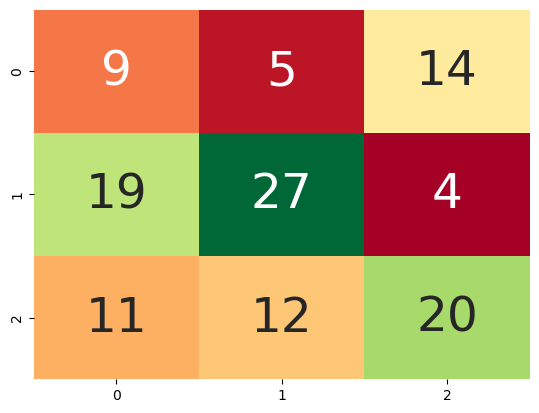

In [373]:
sns.heatmap(cm, annot=True,cbar=False,fmt="d",cmap="RdYlGn",annot_kws={"size": 35})
plt.show()

In [374]:
print('Number of test SMSs : ', TP+TN+FP+FN)
print('Number of actual SPAM SMSs : ', TP+FN)
print('Number of actual HAM SMSs: : ', TN+FP)
print('Number of predected SMSs as SPAM: ', TP+FP)
print('Number of predected SMSs as HAM : ', FN+TN)
 

Number of test SMSs :  60
Number of actual SPAM SMSs :  46
Number of actual HAM SMSs: :  14
Number of predected SMSs as SPAM:  32
Number of predected SMSs as HAM :  28


In [375]:
# Accuracy : the ratio of correct predictions to total predictions made.
Accuracy=(TP+TN)/(TP+TN+FN+FP)
print('Accuracy : ', round(Accuracy,3))


#Precision:Precision: the ratio between the True Positives and all the Positives. 
#For our problem statement, If the spam filter says this email is spam, what’s the probability that it’s spam
Precision = TP / (TP + FP)
print('Precision : ', round(Precision,3))

#Recall: the measure of our model correctly identifying True Positives.
#The all SMSs are Spam ,recall tells us how many we correctly identified as Spam
Recall = TP/(TP + FN)
print('Recall : ', round(Recall,3))


Accuracy :  0.6
Precision :  0.844
Recall :  0.587
